# Day 30 — Project 1: Titanic Survival Predictor
### First end-to-end ML app — training pipeline + Streamlit UI + SHAP explanations

## 1. Project Overview

In [1]:
print("""
PROJECT 1 — TITANIC SURVIVAL PREDICTOR
=======================================

What we built:
  - train_model.py  : full ML pipeline, saves model to disk
  - app.py          : Streamlit web app with SHAP explanations
  - requirements.txt: dependencies for deployment

Tech stack:
  - scikit-learn  : Random Forest classifier
  - SHAP          : model explainability
  - Streamlit     : web UI
  - pickle        : model serialisation

Model performance:
  - CV AUC:   0.8751 ± 0.0157
  - Test AUC: 0.8487
  - Test Acc: 81.56%

Key predictions tested:
  - Male, Mr, 3rd class, age 30  → 15.9% survival ❌
  - Female, Mrs, 1st class, cabin → 93.9% survival ✅

Features used (from Day 22 engineering):
  Pclass, Age, FareLog, FamilySize, IsAlone,
  HasCabin, Sex_encoded, Title_Mr, Title_Mrs,
  Title_Miss, Title_Master
""")


PROJECT 1 — TITANIC SURVIVAL PREDICTOR

What we built:
  - train_model.py  : full ML pipeline, saves model to disk
  - app.py          : Streamlit web app with SHAP explanations
  - requirements.txt: dependencies for deployment

Tech stack:
  - scikit-learn  : Random Forest classifier
  - SHAP          : model explainability
  - Streamlit     : web UI
  - pickle        : model serialisation

Model performance:
  - CV AUC:   0.8751 ± 0.0157
  - Test AUC: 0.8487
  - Test Acc: 81.56%

Key predictions tested:
  - Male, Mr, 3rd class, age 30  → 15.9% survival ❌
  - Female, Mrs, 1st class, cabin → 93.9% survival ✅

Features used (from Day 22 engineering):
  Pclass, Age, FareLog, FamilySize, IsAlone,
  HasCabin, Sex_encoded, Title_Mr, Title_Mrs,
  Title_Miss, Title_Master



## 2. Training Pipeline

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import pickle
import os
import warnings

warnings.filterwarnings("ignore")

# load and clean
df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna("S")
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# feature engineering
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["FareLog"] = np.log1p(df["Fare"])
df["HasCabin"] = df["Cabin"].notna().astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title_map = {"Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master"}
df["Title"] = df["Title"].map(title_map).fillna("Other")
for t in ["Mr", "Mrs", "Miss", "Master"]:
    df[f"Title_{t}"] = (df["Title"] == t).astype(int)

features = [
    "Pclass",
    "Age",
    "FareLog",
    "FamilySize",
    "IsAlone",
    "HasCabin",
    "Sex_encoded",
    "Title_Mr",
    "Title_Mrs",
    "Title_Miss",
    "Title_Master",
]

X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=4, random_state=42)
rf.fit(X_train, y_train)

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="roc_auc")
test_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
test_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"CV AUC:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Acc: {test_acc:.4f}")
print()
print(
    classification_report(y_test, rf.predict(X_test), target_names=["Died", "Survived"])
)

# feature importance
imp_df = pd.DataFrame(
    {"Feature": features, "Importance": rf.feature_importances_}
).sort_values("Importance", ascending=False)

print("Feature Importances:")
for _, row in imp_df.iterrows():
    bar = "█" * int(row["Importance"] * 100)
    print(f"  {row['Feature']:<15} {row['Importance']:.4f} {bar}")

CV AUC:   0.8751 ± 0.0157
Test AUC: 0.8487
Test Acc: 0.8156

              precision    recall  f1-score   support

        Died       0.82      0.89      0.86       110
    Survived       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179

Feature Importances:
  Title_Mr        0.2255 ██████████████████████
  Sex_encoded     0.1880 ██████████████████
  FareLog         0.1649 ████████████████
  Age             0.1081 ██████████
  Pclass          0.0886 ████████
  FamilySize      0.0673 ██████
  HasCabin        0.0576 █████
  Title_Mrs       0.0427 ████
  Title_Miss      0.0374 ███
  IsAlone         0.0115 █
  Title_Master    0.0084 


## 3. SHAP Explainability

Global SHAP importance (mean |SHAP|):
  Title_Mr        0.1200 ████████████
  Sex_encoded     0.0947 █████████
  Pclass          0.0525 █████
  HasCabin        0.0470 ████
  FareLog         0.0441 ████
  FamilySize      0.0248 ██
  Age             0.0233 ██
  Title_Miss      0.0197 █
  Title_Mrs       0.0195 █
  IsAlone         0.0076 
  Title_Master    0.0057 

Baseline survival probability: 0.3850
  = 38.5% average survival rate

--- SHAP breakdown: 1st class female (Mrs) ---
Prediction: 95.8% survival
Feature             SHAP
-------------------------
  Title_Mr        +0.1646 ↑
  Sex_encoded     +0.1371 ↑
  Pclass          +0.0794 ↑
  FareLog         +0.0765 ↑
  HasCabin        +0.0674 ↑
  Title_Mrs       +0.0434 ↑
  FamilySize      +0.0204 ↑
  Title_Miss      -0.0098 ↓
  Age             -0.0037 ↓
  Title_Master    -0.0015 ↓
  IsAlone         -0.0003 ↓

--- SHAP breakdown: 3rd class male (Mr) ---
Prediction: 35.2% survival
Feature             SHAP
-------------------------
  FareLo

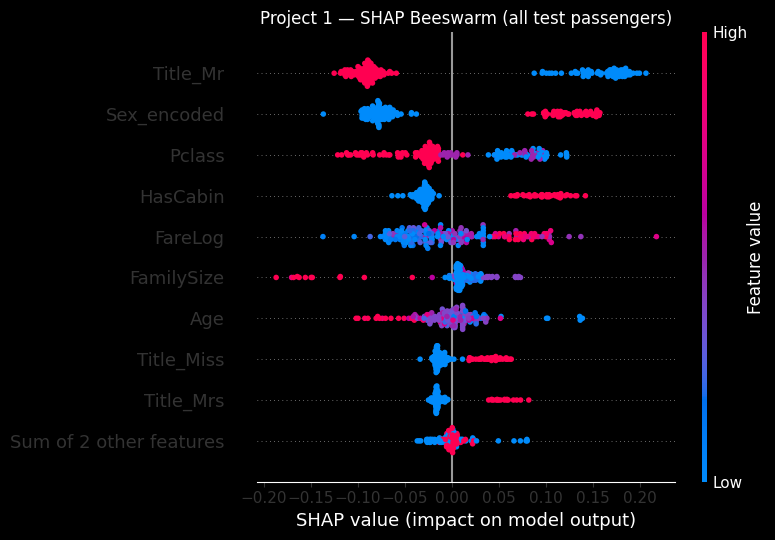

In [ ]:
import shap
import matplotlib.pyplot as plt

plt.style.use("dark_background")

# compute SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)
shap_survived = shap_values[:, :, 1]

# global feature importance
print("Global SHAP importance (mean |SHAP|):")
mean_shap = np.abs(shap_survived.values).mean(axis=0)
shap_df = pd.DataFrame({"Feature": features, "Mean_SHAP": mean_shap}).sort_values(
    "Mean_SHAP", ascending=False
)

for _, row in shap_df.iterrows():
    bar = "█" * int(row["Mean_SHAP"] * 100)
    print(f"  {row['Feature']:<15} {row['Mean_SHAP']:.4f} {bar}")

print(f"\nBaseline survival probability: {shap_values.base_values[0,1]:.4f}")
print(f"  = {shap_values.base_values[0,1]*100:.1f}% average survival rate")

# two test cases — mirrors what app shows
print("\n--- SHAP breakdown: 1st class female (Mrs) ---")
test_passenger_1 = pd.DataFrame(
    [
        {
            "Pclass": 1,
            "Age": 25,
            "FareLog": np.log1p(100),
            "FamilySize": 1,
            "IsAlone": 1,
            "HasCabin": 1,
            "Sex_encoded": 1,
            "Title_Mr": 0,
            "Title_Mrs": 1,
            "Title_Miss": 0,
            "Title_Master": 0,
        }
    ]
)

sv1 = explainer(test_passenger_1)
prob1 = rf.predict_proba(test_passenger_1)[0][1]
print(f"Prediction: {prob1*100:.1f}% survival")
print(f"{'Feature':<15} {'SHAP':>8}")
print("-" * 25)
for feat, val in sorted(
    zip(features, sv1[:, :, 1].values[0]), key=lambda x: abs(x[1]), reverse=True
):
    direction = "↑" if val > 0 else "↓"
    print(f"  {feat:<15} {val:+.4f} {direction}")

print("\n--- SHAP breakdown: 3rd class male (Mr) ---")
test_passenger_2 = pd.DataFrame(
    [
        {
            "Pclass": 3,
            "Age": 30,
            "FareLog": np.log1p(32),
            "FamilySize": 1,
            "IsAlone": 1,
            "HasCabin": 0,
            "Sex_encoded": 0,
            "Title_Mr": 1,
            "Title_Mrs": 0,
            "Title_Miss": 0,
            "Title_Master": 0,
        }
    ]
)

sv2 = explainer(test_passenger_2)
prob2 = rf.predict_proba(test_passenger_2)[0][1]
print(f"Prediction: {prob2*100:.1f}% survival")
print(f"{'Feature':<15} {'SHAP':>8}")
print("-" * 25)
for feat, val in sorted(
    zip(features, sv2[:, :, 1].values[0]), key=lambda x: abs(x[1]), reverse=True
):
    direction = "↑" if val > 0 else "↓"
    print(f"  {feat:<15} {val:+.4f} {direction}")

# beeswarm plot
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_survived, show=False)
plt.title("Project 1 — SHAP Beeswarm (all test passengers)")
plt.tight_layout()
plt.show()

## 4. Key Takeaways — Day 30 Project 1 🎯

### What We Built
- `train_model.py` — full ML pipeline with feature engineering, saves model to disk
- `app.py` — interactive Streamlit web app with real-time predictions
- SHAP explanations — "Why this prediction?" for every passenger
- `requirements.txt` — ready for deployment to Streamlit Cloud

### Model Performance
- CV AUC: 0.8751 ± 0.0157 (stable, low variance)
- Test AUC: 0.8487
- Test Accuracy: 81.56%

### Feature Importances (RF vs SHAP)
| Feature | RF Importance | SHAP |
|---|---|---|
| Title_Mr | 0.226 | 0.120 |
| Sex_encoded | 0.188 | 0.095 |
| FareLog | 0.165 | 0.044 |
| Age | 0.108 | 0.023 |

### Two Test Predictions
| Passenger | Survival Prob | Key drivers |
|---|---|---|
| Female, Mrs, 1st class, cabin | 95.8% ✅ | Title_Mr(not)=+0.165, Sex=+0.137, Pclass=+0.079 |
| Male, Mr, 3rd class | 35.2% ❌ | Sex=-0.069, Title_Mr=-0.068, HasCabin=-0.029 |

### Lessons from Building the App
- Always run train_model.py FROM the project folder (model path is relative!)
- Streamlit auto-reloads on file save — great for development
- SHAP TreeExplainer is fast enough for real-time predictions
- Feature engineering in app.py must EXACTLY mirror train_model.py
- pickle saves the trained model — no need to retrain on app startup

### App Structure